<a href="https://colab.research.google.com/github/rathoretina07/Deep-learning-/blob/main/ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
# Load the data
df = pd.read_csv('/content/allDataMean.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 184426 entries, 0 to 184425
Data columns (total 16 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   allDataMean1   184426 non-null  float64
 1   allDataMean2   184426 non-null  float64
 2   allDataMean3   184426 non-null  float64
 3   allDataMean4   184426 non-null  float64
 4   allDataMean5   184426 non-null  float64
 5   allDataMean6   184426 non-null  float64
 6   allDataMean7   184426 non-null  float64
 7   allDataMean8   184426 non-null  float64
 8   allDataMean9   184426 non-null  float64
 9   allDataMean10  184426 non-null  float64
 10  allDataMean11  184426 non-null  float64
 11  allDataMean12  184426 non-null  float64
 12  allDataMean13  184426 non-null  float64
 13  allDataMean14  184426 non-null  float64
 14  allDataMean15  184426 non-null  float64
 15  allDataMean16  184426 non-null  float64
dtypes: float64(16)
memory usage: 22.5 MB


In [ ]:
# Drop rows
df = df.dropna()
# Separate features and target
X = df.drop(columns=['allDataMean6'])
y = df['allDataMean6']

In [ ]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
# Build ANN model
model = Sequential([
    Dense(128, input_dim=X.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)  # Regression output
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Compile model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])


In [ ]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)


In [ ]:
# Train model
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=1)



Epoch 1/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - loss: 2634.9741 - mae: 30.6756 - val_loss: 347.7028 - val_mae: 13.5054
Epoch 2/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 539.9382 - mae: 16.9957 - val_loss: 303.6972 - val_mae: 12.4972
Epoch 3/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 463.9538 - mae: 15.5967 - val_loss: 228.8136 - val_mae: 11.2065
Epoch 4/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 407.7543 - mae: 14.5097 - val_loss: 198.1808 - val_mae: 9.8108
Epoch 5/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - loss: 377.7009 - mae: 13.9177 - val_loss: 215.4955 - val_mae: 10.7614
Epoch 6/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - loss: 359.0072 - mae: 13.5029 - val_loss: 218.6162 - val_mae: 10.7730
Epoch 7/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 329.3780 - mae: 12.9629 - val_loss: 202.3347 - val_mae: 10.6478
Epoch 8/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 311.3200 - mae: 12.6018 - val_loss: 168.

In [ ]:
# Evaluate on test data
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nTest MSE: {mse:.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test R² Score: {r2:.4f}")


1153/1153 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Test MSE: 172.5339
Test MAE: 9.5116
Test R² Score: 0.9748


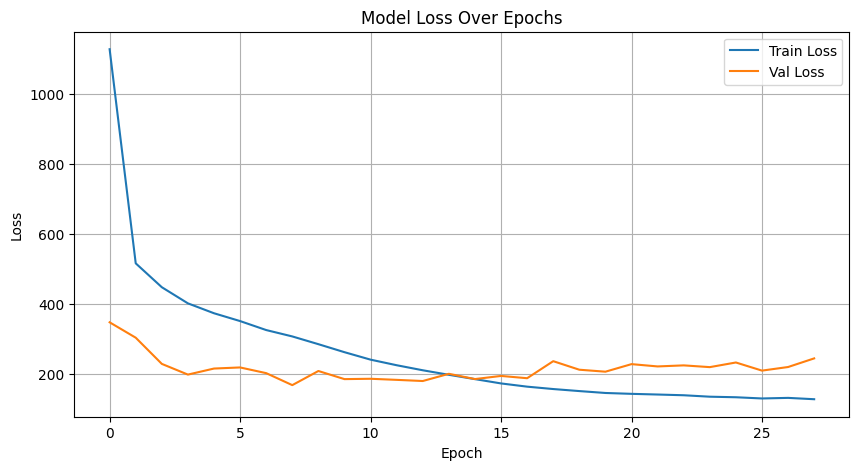

In [ ]:
# Plot loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


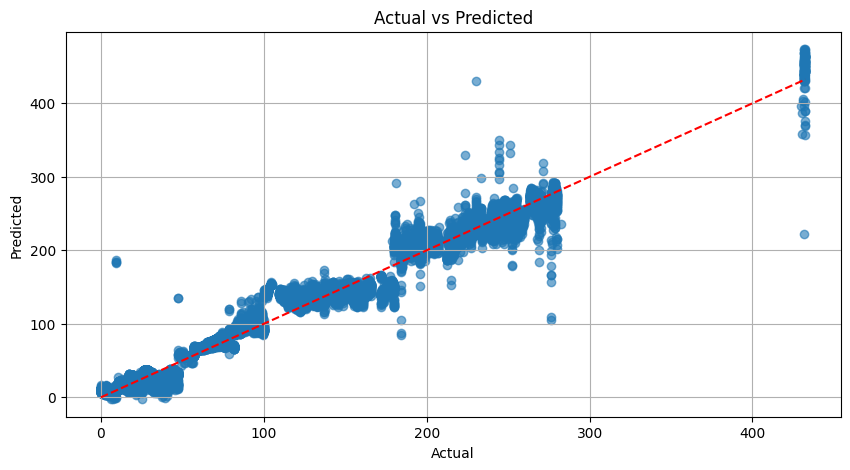

In [ ]:
# Plot actual vs predicted
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid(True)
plt.show()

In [ ]:
pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

from xgboost import XGBRegressor

In [ ]:
# Load data
df = pd.read_csv('/content/allDataMean.csv')
df.dropna(inplace=True)


In [ ]:
# Features and target
X = df.drop(columns=['allDataMean6'])
y = df['allDataMean6']

In [ ]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


In [ ]:
# ANN Model
model = Sequential([
    Dense(128, input_dim=X.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

In [ ]:
history= model.fit(X_train, y_train, validation_split=0.2,epochs=100, batch_size=32, callbacks=[early_stop], verbose=1)

Epoch 1/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - loss: 2510.0054 - mae: 30.3238 - val_loss: 368.0204 - val_mae: 14.4831
Epoch 2/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 553.9515 - mae: 17.2315 - val_loss: 274.0527 - val_mae: 12.2784
Epoch 3/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 453.2233 - mae: 15.4748 - val_loss: 227.2890 - val_mae: 10.7271
Epoch 4/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 397.7620 - mae: 14.4273 - val_loss: 249.3854 - val_mae: 11.6217
Epoch 5/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 363.6411 - mae: 13.7598 - val_loss: 195.9270 - val_mae: 9.7375
Epoch 6/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 344.0089 - mae: 13.2515 - val_loss: 183.4889 - val_mae: 10.0389
Epoch 7/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 307.4977 - mae: 12.5586 - val_loss: 159.3829 - val_mae: 8.7650
Epoch 8/100
3689/3689 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - loss: 283.2753 - mae: 12.0574 - val_loss: 179.2

In [ ]:
# ANN Evaluation
y_pred_ann = model.predict(X_test).flatten()
mse_ann = mean_squared_error(y_test, y_pred_ann)
mae_ann = mean_absolute_error(y_test, y_pred_ann)
r2_ann = r2_score(y_test, y_pred_ann)

print(f" ANN Results:\nMSE: {mse_ann:.4f} | MAE: {mae_ann:.4f} | R²: {r2_ann:.4f}")


1153/1153 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
 ANN Results:
MSE: 76.2192 | MAE: 5.7701 | R²: 0.9889


In [ ]:
# XGBoost with GridSearch
xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

grid = GridSearchCV(xgb, param_grid, scoring='r2', cv=3, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

best_xgb = grid.best_estimator_
y_pred_xgb = best_xgb.predict(X_test)

mse_xgb = mean_squared_error(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\n XGBoost Results (Best Params):\nMSE: {mse_xgb:.4f} | MAE: {mae_xgb:.4f} | R²: {r2_xgb:.4f}")
print("Best Hyperparameters:", grid.best_params_)


NameError: name 'X_train' is not defined

In [ ]:
# ANN Loss Plot
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('ANN Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined

In [ ]:
# XGBoost Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(sorted(y_test.values), label='Actual', linewidth=2)
plt.plot(sorted(y_pred_xgb), label='Predicted (XGBoost)', linewidth=2)
plt.title('Actual vs Predicted - XGBoost')
plt.xlabel('Sample Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined